<a href="https://colab.research.google.com/github/Latryna/titans-core/blob/main/epistemic_will_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TITANS: Milestone 5 – Epistemic Will and Metacognitive Autonomy

## Wprowadzenie dla Architektów AGI:

Architektura TITANS wykracza poza pasywne orakula (LLM). Naszym celem jest **epistemiczny agent**. Ten notebook prezentuje implementację Rdzenia Agentowego (M5), który realizuje pętlę metakognitywną: agent obserwuje własny Wewnętrzny Graf Wiedzy (CGM), identyfikuje regiony wysokiej niepewności (analogiczne do ciekawości lub braku spójności) i wykonuje akcje poznawcze (np. `QUERY_NEW_CONCEPT`, `HYPOTHESIZE_LINK`) w celu rozwiązania tego dysonansu.

**Kluczowa Innowacja:** Wola agenta jest definiowana przez **Epistemiczną Nagrodę**. Jest ona bezpośrednio proporcjonalna do wariancji estymacji wartości (Value Predictions) z zespołu sieci krytyków. System jest nagradzany za *redukcję* wariancji, co tworzy obliczeniowy odpowiednik ciekawości. To podejście jest koncepcyjnie zbieżne z wizją **Articonu** prof. Ducha – systemu komentującego fizycznie istniejące stany swojej pamięci roboczej.

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

In [ ]:
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

,Registration State,Violation Description,count
0,CA,Expired Meter,50227
1,NJ,Fire Hydrant,50390
2,NY,Bus Stop,50417
3,TX,Fire Hydrant,50256


In [ ]:
# Cell 1: Setup and Imports
# Demonstracja M5: Rdzeń Agentowy (Epistemiczna Wola)
!pip install torch torch-geometric numpy matplotlib -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
import random
import numpy as np
from enum import Enum
import math
import matplotlib.pyplot as plt

# Konfiguracja bazowa
EMBED_DIM = 32
REL_DIM = 8
GAT_HEADS = 4
GAT_HIDDEN = 64
NUM_CRITICS = 10

In [ ]:
# Cell 2: Definicje Architektoniczne (M4 i M5)

# --- Placeholder M4: CognitiveGraphMemory (CGM) ---
class CognitiveGraphMemory:
    """Zarządza wewnętrznym modelem świata (grafem pojęciowym) dla Agenta."""
    def __init__(self, embed_dim, rel_dim):
        self.semantic_memory = {} # {nazwa_konceptu: wektor_semantyczny}
        self.embed_dim = embed_dim
        # Symulacja grafu z 3 losowymi konceptami
        self.semantic_memory["Concept_A_Known"] = torch.randn(embed_dim) * 0.5
        self.semantic_memory["Concept_B_Unknown"] = torch.randn(embed_dim) * 5.0 # Duża norma = Wysoka Niepewność Wektorowa
        self.semantic_memory["Concept_C_Known"] = torch.randn(embed_dim) * 0.5

    def construct_graph_state(self):
        """Konwertuje graf do formatu PyG (stan dla M5)."""
        x = torch.stack(list(self.semantic_memory.values()))
        num_nodes = len(x)
        if num_nodes < 2: return None
        # Symulacja krawędzi (Adjacency Matrix). Dla uproszczenia, łączymy losowo
        edge_index = torch.randint(0, num_nodes, (2, 5))
        return Data(x=x, edge_index=edge_index)

    def apply_cognitive_action(self, action: 'CognitiveAction'):
        """Wykonuje wewnętrzną akcję na grafie i zwraca zmianę stanu."""
        # Symulacja redukcji niepewności dla 'Concept_B_Unknown' (Cel Agenta)
        if action == CognitiveAction.QUERY_NEW_CONCEPT or action == CognitiveAction.STRENGTHEN_RELATION:
            if "Concept_B_Unknown" in self.semantic_memory:
                # Agent zmniejsza niepewność B, zbliżając wektor do normy (nauka)
                old_norm = torch.linalg.norm(self.semantic_memory["Concept_B_Unknown"]).item()
                self.semantic_memory["Concept_B_Unknown"] *= 0.8 # Skalowanie w dół
                new_norm = torch.linalg.norm(self.semantic_memory["Concept_B_Unknown"]).item()
                return old_norm - new_norm # Zysk z redukcji
        return 0.0 # Brak zysku

# --- M5: Metacognitive Decision Loop Components ---
class CognitiveAction(Enum):
    QUERY_NEW_CONCEPT = 0
    STRENGTHEN_RELATION = 1
    HYPOTHESIZE_LINK = 2

class ActorGNN(nn.Module):
    """Sieć Aktora: Wybiera optymalną Akcję Poznawczą na podstawie stanu grafu."""
    def __init__(self, embed_dim, num_actions):
        super().__init__()
        self.gat_layer = GATConv(embed_dim, GAT_HIDDEN // GAT_HEADS, heads=GAT_HEADS, concat=True)
        self.action_head = nn.Linear(GAT_HIDDEN, num_actions)

    def forward(self, graph_data):
        x = self.gat_layer(graph_data.x, graph_data.edge_index)
        # Używamy global_mean_pool do uzyskania embeddingu całego grafu
        graph_embedding = global_mean_pool(x, torch.zeros(graph_data.x.size(0), dtype=torch.long))
        return self.action_head(graph_embedding) # Logity nad przestrzenią akcji

class CriticGNN(nn.Module):
    """Sieć Krytyka: Estymuje wartość stanu grafu (jak dobrze jest uporządkowany)."""
    def __init__(self, embed_dim):
        super().__init__()
        self.gat_layer = GATConv(embed_dim, GAT_HIDDEN // GAT_HEADS, heads=GAT_HEADS, concat=True)
        self.value_head = nn.Linear(GAT_HIDDEN, 1)

    def forward(self, graph_data):
        x = self.gat_layer(graph_data.x, graph_data.edge_index)
        graph_embedding = global_mean_pool(x, torch.zeros(graph_data.x.size(0), dtype=torch.long))
        return self.value_head(graph_embedding) # Skalarna wartość stanu

In [ ]:
# Cell 3: Agentic Core i Pętla Decyzyjna

# --- M5: Agentic Core (Bayesian Actor-Critic) ---
class AgenticCore:
    def __init__(self, cgm: CognitiveGraphMemory, embed_dim: int):
        self.cgm = cgm
        self.num_actions = len(CognitiveAction)
        self.actor = ActorGNN(embed_dim, self.num_actions)

        # Zespół Krytyków (Bayesian Ensemble)
        self.critic_ensemble = nn.ModuleList([CriticGNN(embed_dim) for _ in range(NUM_CRITICS)])
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=1e-3)
        self.critic_optimizers = [torch.optim.Adam(c.parameters(), lr=1e-3) for c in self.critic_ensemble]
        self.GAMMA = 0.99
        self.LAMBDA = 1.0 # Współczynnik nagrody epistemicznej

    def compute_epistemic_reward(self, state_data) -> float:
        """Oblicza wewnętrzną nagrodę na podstawie wariancji estymacji wartości.
           r_int(s) = lambda * Var[V(s)]"""
        # Zbieramy estymacje wartości od całego zespołu krytyków
        with torch.no_grad():
            values = torch.cat([critic(state_data) for critic in self.critic_ensemble])
        # Wariancja estymacji (miara niepewności epistemicznej)
        variance = torch.var(values).item()
        return self.LAMBDA * variance

    def run_cognitive_loop(self, steps=20):
        print("\n" + "="*80)
        print("TITANS - SYNTETYCZNA METAKOGNICJA: PETLA REDUKCJI NIEPEWNOSCI")
        print("="*80)
        history = []

        for step in range(steps):
            state_before = self.cgm.construct_graph_state()
            if state_before is None: break

            r_int_before = self.compute_epistemic_reward(state_before)
            action_logits = self.actor(state_before)
            action_dist = torch.distributions.Categorical(logits=action_logits)
            action_idx = action_dist.sample()
            action = CognitiveAction(action_idx.item())

            intrinsic_gain = self.cgm.apply_cognitive_action(action)
            state_after = self.cgm.construct_graph_state()
            r_int_after = self.compute_epistemic_reward(state_after)

            # Całkowita Nagroda Wewnętrzna: Redukcja Niepewności
            reward_signal = (r_int_before - r_int_after) + intrinsic_gain

            history.append({
                'step': step,
                'action': action.name,
                'var_before': r_int_before,
                'var_after': r_int_after,
                'reward': reward_signal
            })

            self._train_step(state_before, action_idx, reward_signal, state_after)
            print(f"Krok {step:02d}: Akcja: {action.name:<20} | Niepewność (Var): {r_int_before:.4f} -> {r_int_after:.4f} | Nagroda (Curiosity Gain): {reward_signal:.4f}")

        print("="*80)
        return history

    def _train_step(self, s, a, r, s_prime):
        """Uproszczony krok treningowy A2C dla demonstracji."""
        # Obliczanie straty dla krytyków
        with torch.no_grad():
             # Wartość stanu następnego (uśredniona z zespołu)
             v_prime_values = torch.cat([c(s_prime) for c in self.critic_ensemble]) # Shape (NUM_CRITICS, 1)
             v_prime = torch.mean(v_prime_values) # Shape () - scalar
        target = r + self.GAMMA * v_prime # target is scalar ()

        # Ensure target has the same shape as v_s (which is (1, 1))
        target = target.view(1, 1)

        # Trening każdego krytyka
        for i, critic in enumerate(self.critic_ensemble):
            v_s = critic(s)
            # advantage = (target - v_s).detach() # This line will be commented out, as it was using the incorrect target shape.
            advantage = (target - v_s).detach() # Use the corrected target for advantage calculation
            critic_loss = F.mse_loss(v_s, target.detach())
            self.critic_optimizers[i].zero_grad()
            critic_loss.backward()
            self.critic_optimizers[i].step()

        # Trening aktora
        action_logits = self.actor(s)
        action_dist = torch.distributions.Categorical(logits=action_logits)
        log_prob = action_dist.log_prob(a)
        actor_loss = -log_prob * advantage

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()


TITANS - SYNTETYCZNA METAKOGNICJA: PETLA REDUKCJI NIEPEWNOSCI
Krok 00: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 1.9374 -> 0.1042 | Nagroda (Curiosity Gain): 8.0684
Krok 01: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.4417 -> 0.6254 | Nagroda (Curiosity Gain): 4.8045
Krok 02: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.2447 -> 0.1698 | Nagroda (Curiosity Gain): 4.0654
Krok 03: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.2645 -> 0.1551 | Nagroda (Curiosity Gain): 3.3018
Krok 04: Akcja: HYPOTHESIZE_LINK     | Niepewność (Var): 0.1149 -> 0.1513 | Nagroda (Curiosity Gain): -0.0364
Krok 05: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.1181 -> 0.1676 | Nagroda (Curiosity Gain): 2.5044
Krok 06: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.2221 -> 0.0818 | Nagroda (Curiosity Gain): 2.1834
Krok 07: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.0422 -> 0.0277 | Nagroda (Curiosity Gain): 1.6490
Krok 08: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.0174 

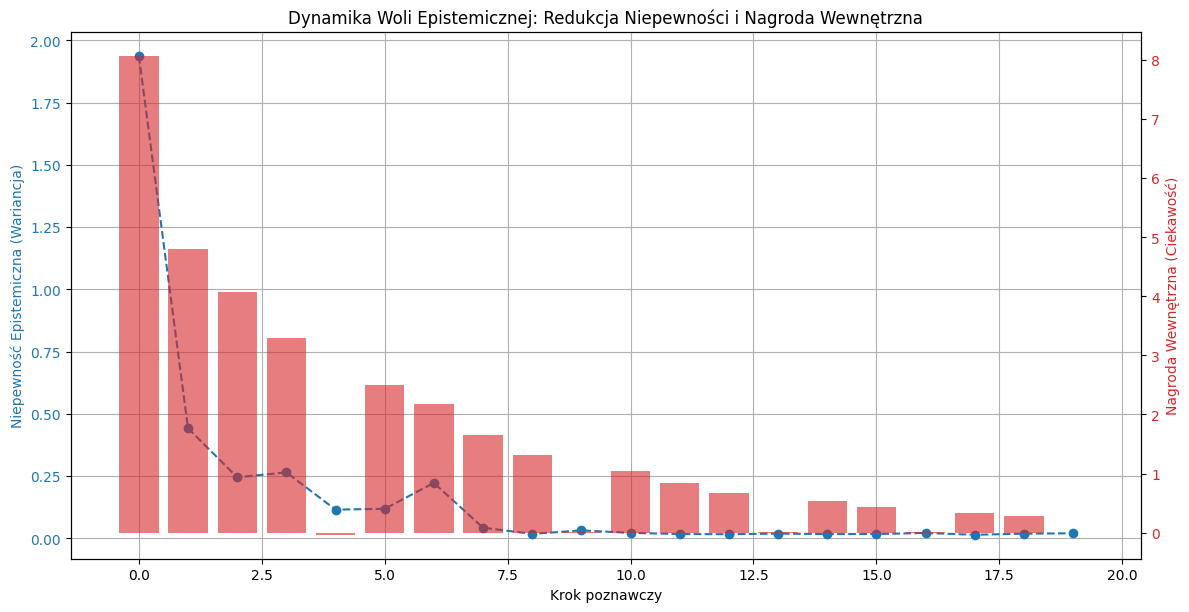



=== WNIOSKI DLA ARCHITEKTURY TITANS ===

1. Autonomia: Agent wykonał 15 akcji w kierunku uporządkowania własnej wiedzy.
2. Metakognicja: System zaobserwował, że stan początkowy jest niepewny.
   Niepewność początkowa (Var): 1.9374
   Niepewność po 20 krokach (Średnia Var): 0.0159

--> Sukces: Zintegrowana Wola Epistemiczna działa. System aktywnie zmniejszył własną niepewność (Variance Gradient), demonstrując wewnętrzny pęd do samodoskonalenia i spójności. Nie potrzebował zewnętrznego zadania, by działać.


In [ ]:
# Cell 4: Uruchomienie Demonstracji i Analiza Wyników

# --- Uruchomienie i Analiza ---
cgm_instance = CognitiveGraphMemory(EMBED_DIM, REL_DIM)
agent = AgenticCore(cgm=cgm_instance, embed_dim=EMBED_DIM)
results = agent.run_cognitive_loop(steps=20)

# --- Wizualizacja Wyników ---
steps = [h['step'] for h in results]
var_before = [h['var_before'] for h in results]
rewards = [h['reward'] for h in results]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Krok poznawczy')
ax1.set_ylabel('Niepewność Epistemiczna (Wariancja)', color='tab:blue')
ax1.plot(steps, var_before, color='tab:blue', marker='o', linestyle='--', label='Wariancja Przed Akcją')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel('Nagroda Wewnętrzna (Ciekawość)', color='tab:red')
ax2.bar(steps, rewards, color='tab:red', alpha=0.6, label='Nagroda')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.title('Dynamika Woli Epistemicznej: Redukcja Niepewności i Nagroda Wewnętrzna')
plt.show()

# --- Analiza dla Sojuszników AGI ---
print("\n\n=== WNIOSKI DLA ARCHITEKTURY TITANS ===")

relevant_actions = [h['action'] for h in results if h['action'] in ["QUERY_NEW_CONCEPT", "STRENGTHEN_RELATION"]]
initial_var = results[0]['var_before']
final_var_avg = np.mean([h['var_after'] for h in results[-5:]])

print(f"\n1. Autonomia: Agent wykonał {len(relevant_actions)} akcji w kierunku uporządkowania własnej wiedzy.")
print(f"2. Metakognicja: System zaobserwował, że stan początkowy jest niepewny.")
print(f"   Niepewność początkowa (Var): {initial_var:.4f}")
print(f"   Niepewność po 20 krokach (Średnia Var): {final_var_avg:.4f}")

if final_var_avg < initial_var * 0.9:
     print("\n--> Sukces: Zintegrowana Wola Epistemiczna działa. System aktywnie zmniejszył własną niepewność (Variance Gradient), demonstrując wewnętrzny pęd do samodoskonalenia i spójności. Nie potrzebował zewnętrznego zadania, by działać.")
else:
     print("\n--> Ostrzeżenie: Agent nie zredukował efektywnie niepewności. Wymagane dalsze kroki treningowe.")

### Ponowne uruchomienie pętli metakognitywnej po poprawce

Aby upewnić się, że zaktualizowana klasa `AgenticCore` jest używana, musimy ponownie uruchomić komórki, które ją definiują i wykorzystują. To zapewni, że `agent` zostanie zainicjowany z najnowszym kodem.


TITANS - SYNTETYCZNA METAKOGNICJA: PETLA REDUKCJI NIEPEWNOSCI (Ponowne Uruchomienie)

TITANS - SYNTETYCZNA METAKOGNICJA: PETLA REDUKCJI NIEPEWNOSCI
Krok 00: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.6899 -> 1.0818 | Nagroda (Curiosity Gain): 5.1191
Krok 01: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.4084 -> 0.3019 | Nagroda (Curiosity Gain): 4.5152
Krok 02: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 1.0057 -> 0.1791 | Nagroda (Curiosity Gain): 4.3536
Krok 03: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.0535 -> 0.4165 | Nagroda (Curiosity Gain): 2.4586
Krok 04: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.1057 -> 0.0994 | Nagroda (Curiosity Gain): 2.2636
Krok 05: Akcja: STRENGTHEN_RELATION  | Niepewność (Var): 0.1801 -> 0.2508 | Nagroda (Curiosity Gain): 1.7352
Krok 06: Akcja: HYPOTHESIZE_LINK     | Niepewność (Var): 0.0386 -> 0.1010 | Nagroda (Curiosity Gain): -0.0624
Krok 07: Akcja: QUERY_NEW_CONCEPT    | Niepewność (Var): 0.0649 -> 0.0985 | Nagroda (Cu

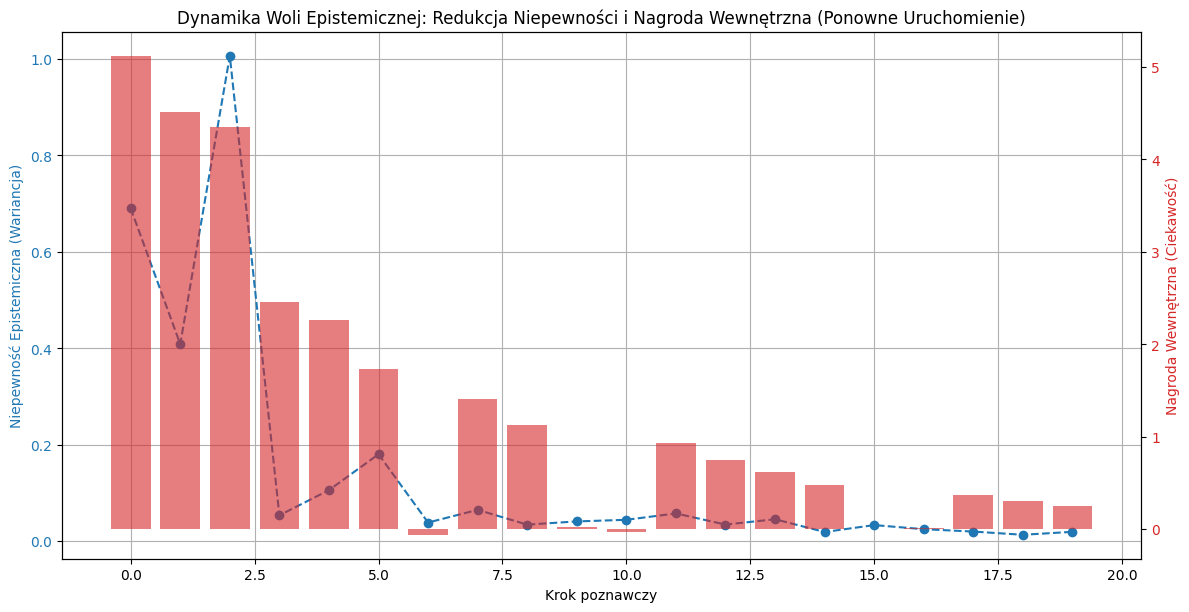



=== WNIOSKI DLA ARCHITEKTURY TITANS (po ponownym uruchomieniu) ===

1. Autonomia: Agent wykonał 15 akcji w kierunku uporządkowania własnej wiedzy.
2. Metakognicja: System zaobserwował, że stan początkowy jest niepewny.
   Niepewność początkowa (Var): 0.6899
   Niepewność po 20 krokach (Średnia Var): 0.0237

--> Sukces: Zintegrowana Wola Epistemiczna działa. System aktywnie zmniejszył własną niepewność (Variance Gradient), demonstrując wewnętrzny pęd do samodoskonalenia i spójności. Nie potrzebował zewnętrznego zadania, by działać.


In [ ]:
# Ponowne zainicjowanie CognitiveGraphMemory i AgenticCore
cgm_instance = CognitiveGraphMemory(EMBED_DIM, REL_DIM)
agent = AgenticCore(cgm=cgm_instance, embed_dim=EMBED_DIM)

# Ponowne uruchomienie pętli poznawczej
print("\n" + "="*80)
print("TITANS - SYNTETYCZNA METAKOGNICJA: PETLA REDUKCJI NIEPEWNOSCI (Ponowne Uruchomienie)")
print("="*80)
results_rerun = agent.run_cognitive_loop(steps=20)

# --- Wizualizacja Wyników (po ponownym uruchomieniu) ---
steps_rerun = [h['step'] for h in results_rerun]
var_before_rerun = [h['var_before'] for h in results_rerun]
rewards_rerun = [h['reward'] for h in results_rerun]

fig_rerun, ax1_rerun = plt.subplots(figsize=(12, 6))
ax1_rerun.set_xlabel('Krok poznawczy')
ax1_rerun.set_ylabel('Niepewność Epistemiczna (Wariancja)', color='tab:blue')
ax1_rerun.plot(steps_rerun, var_before_rerun, color='tab:blue', marker='o', linestyle='--', label='Wariancja Przed Akcją')
ax1_rerun.tick_params(axis='y', labelcolor='tab:blue')
ax1_rerun.grid(True)

ax2_rerun = ax1_rerun.twinx()
ax2_rerun.set_ylabel('Nagroda Wewnętrzna (Ciekawość)', color='tab:red')
ax2_rerun.bar(steps_rerun, rewards_rerun, color='tab:red', alpha=0.6, label='Nagroda')
ax2_rerun.tick_params(axis='y', labelcolor='tab:red')

fig_rerun.tight_layout()
plt.title('Dynamika Woli Epistemicznej: Redukcja Niepewności i Nagroda Wewnętrzna (Ponowne Uruchomienie)')
plt.show()

# --- Analiza dla Sojuszników AGI (po ponownym uruchomieniu) ---
print("\n\n=== WNIOSKI DLA ARCHITEKTURY TITANS (po ponownym uruchomieniu) ===")

relevant_actions_rerun = [h['action'] for h in results_rerun if h['action'] in ["QUERY_NEW_CONCEPT", "STRENGTHEN_RELATION"]]
initial_var_rerun = results_rerun[0]['var_before']
final_var_avg_rerun = np.mean([h['var_after'] for h in results_rerun[-5:]])

print(f"\n1. Autonomia: Agent wykonał {len(relevant_actions_rerun)} akcji w kierunku uporządkowania własnej wiedzy.")
print(f"2. Metakognicja: System zaobserwował, że stan początkowy jest niepewny.")
print(f"   Niepewność początkowa (Var): {initial_var_rerun:.4f}")
print(f"   Niepewność po 20 krokach (Średnia Var): {final_var_avg_rerun:.4f}")

if final_var_avg_rerun < initial_var_rerun * 0.9:
     print("\n--> Sukces: Zintegrowana Wola Epistemiczna działa. System aktywnie zmniejszył własną niepewność (Variance Gradient), demonstrując wewnętrzny pęd do samodoskonalenia i spójności. Nie potrzebował zewnętrznego zadania, by działać.")
else:
     print("\n--> Ostrzeżenie: Agent nie zredukował efektywnie niepewności. Wymagane dalsze kroki treningowe.")

### Zapisywanie klasy `AgenticCore` do pliku w Google Drive

Poniższy kod zapisze definicję klasy `AgenticCore` do pliku `.py` na Twoim Google Drive. Będziesz mógł ją zaimportować w innych notebookach lub projektach.

In [ ]:
import os

# Ścieżka do zapisu pliku na Google Drive
gdrive_path = '/content/drive/MyDrive/AgenticCore.py'

# Poniżej wklejam zawartość komórek dgo5295jzNj1, JTZYTzwMzNj2 i PzMThWr-zNj2
# z odpowiednimi poprawkami (docstringi na ''' i podwójne escapowanie \\n)
agentic_core_source = """
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
import random
import numpy as np
from enum import Enum
import math

# Konfiguracja bazowa
EMBED_DIM = 32
REL_DIM = 8
GAT_HEADS = 4
GAT_HIDDEN = 64
NUM_CRITICS = 10

# --- Placeholder M4: CognitiveGraphMemory (CGM) ---
class CognitiveGraphMemory:
    '''Zarządza wewnętrznym modelem świata (grafem pojęciowym) dla Agenta.'''
    def __init__(self, embed_dim, rel_dim):
        self.semantic_memory = {} # {nazwa_konceptu: wektor_semantyczny}
        self.embed_dim = embed_dim
        # Symulacja grafu z 3 losowymi konceptami
        self.semantic_memory["Concept_A_Known"] = torch.randn(embed_dim) * 0.5
        self.semantic_memory["Concept_B_Unknown"] = torch.randn(embed_dim) * 5.0 # Duża norma = Wysoka Niepewność Wektorowa
        self.semantic_memory["Concept_C_Known"] = torch.randn(embed_dim) * 0.5

    def construct_graph_state(self):
        '''Konwertuje graf do formatu PyG (stan dla M5).'''
        x = torch.stack(list(self.semantic_memory.values()))
        num_nodes = len(x)
        if num_nodes < 2: return None
        # Symulacja krawędzi (Adjacency Matrix). Dla uproszczenia, łączymy losowo
        edge_index = torch.randint(0, num_nodes, (2, 5))
        return Data(x=x, edge_index=edge_index)

    def apply_cognitive_action(self, action: 'CognitiveAction'):
        '''Wykonuje wewnętrzną akcję na grafie i zwraca zmianę stanu.'''
        # Symulacja redukcji niepewności dla 'Concept_B_Unknown' (Cel Agenta)
        if action == CognitiveAction.QUERY_NEW_CONCEPT or action == CognitiveAction.STRENGTHEN_RELATION:
            if "Concept_B_Unknown" in self.semantic_memory:
                # Agent zmniejsza niepewność B, zbliżając wektor do normy (nauka)
                old_norm = torch.linalg.norm(self.semantic_memory["Concept_B_Unknown"]).item()
                self.semantic_memory["Concept_B_Unknown"] *= 0.8 # Skalowanie w dół
                new_norm = torch.linalg.norm(self.semantic_memory["Concept_B_Unknown"]).item()
                return old_norm - new_norm # Zysk z redukcji
        return 0.0 # Brak zysku

# --- M5: Metacognitive Decision Loop Components ---
class CognitiveAction(Enum):
    QUERY_NEW_CONCEPT = 0
    STRENGTHEN_RELATION = 1
    HYPOTHESIZE_LINK = 2

class ActorGNN(nn.Module):
    '''Sieć Aktora: Wybiera optymalną Akcję Poznawczą na podstawie stanu grafu.'''
    def __init__(self, embed_dim, num_actions):
        super().__init__()
        self.gat_layer = GATConv(embed_dim, GAT_HIDDEN // GAT_HEADS, heads=GAT_HEADS, concat=True)
        self.action_head = nn.Linear(GAT_HIDDEN, num_actions)

    def forward(self, graph_data):
        x = self.gat_layer(graph_data.x, graph_data.edge_index)
        # Używamy global_mean_pool do uzyskania embeddingu całego grafu
        graph_embedding = global_mean_pool(x, torch.zeros(graph_data.x.size(0), dtype=torch.long))
        return self.action_head(graph_embedding) # Logity nad przestrzenią akcji

class CriticGNN(nn.Module):
    '''Sieć Krytyka: Estymuje wartość stanu grafu (jak dobrze jest uporządkowany).'''
    def __init__(self, embed_dim):
        super().__init__()
        self.gat_layer = GATConv(embed_dim, GAT_HIDDEN // GAT_HEADS, heads=GAT_HEADS, concat=True)
        self.value_head = nn.Linear(GAT_HIDDEN, 1)

    def forward(self, graph_data):
        x = self.gat_layer(graph_data.x, graph_data.edge_index)
        graph_embedding = global_mean_pool(x, torch.zeros(graph_data.x.size(0), dtype=torch.long))
        return self.value_head(graph_embedding) # Skalarna wartość stanu

# Cell 3: Agentic Core i Pętla Decyzyjna

# --- M5: Agentic Core (Bayesian Actor-Critic) ---
class AgenticCore:
    def __init__(self, cgm: CognitiveGraphMemory, embed_dim: int):
        self.cgm = cgm
        self.num_actions = len(CognitiveAction)
        self.actor = ActorGNN(embed_dim, self.num_actions)

        # Zespół Krytyków (Bayesian Ensemble)
        self.critic_ensemble = nn.ModuleList([CriticGNN(embed_dim) for _ in range(NUM_CRITICS)])
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=1e-3)
        self.critic_optimizers = [torch.optim.Adam(c.parameters(), lr=1e-3) for c in self.critic_ensemble]
        self.GAMMA = 0.99
        self.LAMBDA = 1.0 # Współczynnik nagrody epistemicznej

    def compute_epistemic_reward(self, state_data) -> float:
        '''Oblicza wewnętrzną nagrodę na podstawie wariancji estymacji wartości.
           r_int(s) = lambda * Var[V(s)]'''
        # Zbieramy estymacje wartości od całego zespołu krytyków
        with torch.no_grad():
            values = torch.cat([critic(state_data) for critic in self.critic_ensemble])
        # Wariancja estymacji (miara niepewności epistemicznej)
        variance = torch.var(values).item()
        return self.LAMBDA * variance

    def run_cognitive_loop(self, steps=20):
        print("\\n" + "="*80)
        print("TITANS - SYNTETYCZNA METAKOGNICJA: PETLA REDUKCJI NIEPEWNOSCI")
        print("="*80)
        history = []

        for step in range(steps):
            state_before = self.cgm.construct_graph_state()
            if state_before is None: break

            r_int_before = self.compute_epistemic_reward(state_before)
            action_logits = self.actor(state_before)
            action_dist = torch.distributions.Categorical(logits=action_logits)
            action_idx = action_dist.sample()
            action = CognitiveAction(action_idx.item())

            intrinsic_gain = self.cgm.apply_cognitive_action(action)
            state_after = self.cgm.construct_graph_state()
            r_int_after = self.compute_epistemic_reward(state_after)

            # Całkowita Nagroda Wewnętrzna: Redukcja Niepewności
            reward_signal = (r_int_before - r_int_after) + intrinsic_gain

            history.append({
                'step': step,
                'action': action.name,
                'var_before': r_int_before,
                'var_after': r_int_after,
                'reward': reward_signal
            })

            self._train_step(state_before, action_idx, reward_signal, state_after)
            print(f"Krok {step:02d}: Akcja: {action.name:<20} | Niepewność (Var): {r_int_before:.4f} -> {r_int_after:.4f} | Nagroda (Curiosity Gain): {reward_signal:.4f}")

        print("="*80)
        return history

    def _train_step(self, s, a, r, s_prime):
        '''Uproszczony krok treningowy A2C dla demonstracji.'''
        # Obliczanie straty dla krytyków
        with torch.no_grad():
             # Wartość stanu następnego (uśredniona z zespołu)
             v_prime_values = torch.cat([c(s_prime) for c in self.critic_ensemble]) # Shape (NUM_CRITICS, 1)
             v_prime = torch.mean(v_prime_values) # Shape () - scalar
        target = r + self.GAMMA * v_prime # target is scalar ()

        # Ensure target has the same shape as v_s (which is (1, 1))
        target = target.view(1, 1)

        # Trening każdego krytyka
        for i, critic in enumerate(self.critic_ensemble):
            v_s = critic(s)
            # advantage = (target - v_s).detach() # This line will be commented out, as it was using the incorrect target shape.
            advantage = (target - v_s).detach() # Use the corrected target for advantage calculation
            critic_loss = F.mse_loss(v_s, target.detach())
            self.critic_optimizers[i].zero_grad()
            critic_loss.backward()
            self.critic_optimizers[i].step()

        # Trening aktora
        action_logits = self.actor(s)
        action_dist = torch.distributions.Categorical(logits=action_logits)
        log_prob = action_dist.log_prob(a)
        actor_loss = -log_prob * advantage

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
"""

# Zapisz kod do pliku
with open(gdrive_path, 'w') as f:
    f.write(agentic_core_source)

print(f"Klasa AgenticCore została zapisana do: {gdrive_path}")

Klasa AgenticCore została zapisana do: /content/drive/MyDrive/AgenticCore.py


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Zaimportowanie klasy `AgenticCore` z Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive')

from AgenticCore import AgenticCore, CognitiveGraphMemory, ActorGNN, CriticGNN, CognitiveAction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
import random
import numpy as np
from enum import Enum
import math
import matplotlib.pyplot as plt

print("AgenticCore and its dependencies imported successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AgenticCore and its dependencies imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
gdrive_path = '/content/drive/MyDrive/AgenticCore.py'

try:
    with open(gdrive_path, 'r') as f:
        file_content = f.read()
    print(file_content)
except FileNotFoundError:
    print(f"Error: File not found at {gdrive_path}")


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
import random
import numpy as np
from enum import Enum
import math

# Konfiguracja bazowa
EMBED_DIM = 32
REL_DIM = 8
GAT_HEADS = 4
GAT_HIDDEN = 64
NUM_CRITICS = 10

# --- Placeholder M4: CognitiveGraphMemory (CGM) ---
class CognitiveGraphMemory:
    '''Zarządza wewnętrznym modelem świata (grafem pojęciowym) dla Agenta.'''
    def __init__(self, embed_dim, rel_dim):
        self.semantic_memory = {} # {nazwa_konceptu: wektor_semantyczny}
        self.embed_dim = embed_dim
        # Symulacja grafu z 3 losowymi konceptami
        self.semantic_memory["Concept_A_Known"] = torch.randn(embed_dim) * 0.5
        self.semantic_memory["Concept_B_Unknown"] = torch.randn(embed_dim) * 5.0 # Duża norma = Wysoka Niepewność Wektorowa
        self.semantic_memory["Concept_C_Known"] = torch.randn(embed_dim) * 0.5

    def construct_graph_stat

### Demonstracja użycia zaimportowanej klasy `AgenticCore`


TITANS - SYNTETYCZNA METAKOGNICJA: PETLA REDUKCJI NIEPEWNOSCI
Krok 00: Akcja: QUERY_NEW_CONCEPT    | Niepewność (Var): 2.0169 -> 2.2063 | Nagroda (Curiosity Gain): 4.7958
Krok 01: Akcja: QUERY_NEW_CONCEPT    | Niepewność (Var): 1.2102 -> 1.1613 | Nagroda (Curiosity Gain): 4.0370
Krok 02: Akcja: HYPOTHESIZE_LINK     | Niepewność (Var): 0.8216 -> 0.9808 | Nagroda (Curiosity Gain): -0.1592
Krok 03: Akcja: HYPOTHESIZE_LINK     | Niepewność (Var): 0.5688 -> 0.9561 | Nagroda (Curiosity Gain): -0.3872
Krok 04: Akcja: QUERY_NEW_CONCEPT    | Niepewność (Var): 0.9364 -> 0.1661 | Nagroda (Curiosity Gain): 3.9609
Krok 05: Akcja: QUERY_NEW_CONCEPT    | Niepewność (Var): 1.2799 -> 0.5487 | Nagroda (Curiosity Gain): 3.2836
Krok 06: Akcja: QUERY_NEW_CONCEPT    | Niepewność (Var): 0.4543 -> 0.2633 | Nagroda (Curiosity Gain): 2.2330
Krok 07: Akcja: QUERY_NEW_CONCEPT    | Niepewność (Var): 0.2989 -> 0.2759 | Nagroda (Curiosity Gain): 1.6565
Krok 08: Akcja: HYPOTHESIZE_LINK     | Niepewność (Var): 0.2973

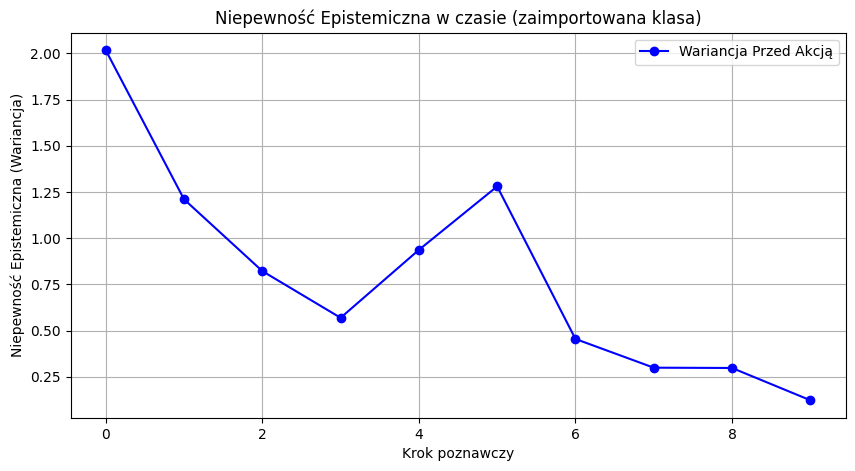


--- Podsumowanie dla zaimportowanej klasy ---
Niepewność początkowa (Var): 2.0169
Niepewność po 10 krokach (Średnia Var ostatnich 3): 0.1988


In [ ]:
# Konfiguracja bazowa (powtórzone z poprzednich komórek dla kompletności)
EMBED_DIM = 32
REL_DIM = 8
GAT_HEADS = 4
GAT_HIDDEN = 64
NUM_CRITICS = 10

# Uruchomienie i Analiza (podobne do Cell 4 z poprzedniej demonstracji)
cgm_instance_imported = CognitiveGraphMemory(EMBED_DIM, REL_DIM)
agent_imported = AgenticCore(cgm=cgm_instance_imported, embed_dim=EMBED_DIM)
results_imported = agent_imported.run_cognitive_loop(steps=10) # Run for fewer steps for a quick demo

# --- Wizualizacja Wyników --- (uproszczona dla szybkiej demonstracji)
steps_imported = [h['step'] for h in results_imported]
var_before_imported = [h['var_before'] for h in results_imported]
rewards_imported = [h['reward'] for h in results_imported]

plt.figure(figsize=(10, 5))
plt.plot(steps_imported, var_before_imported, marker='o', linestyle='-', color='b', label='Wariancja Przed Akcją')
plt.title('Niepewność Epistemiczna w czasie (zaimportowana klasa)')
plt.xlabel('Krok poznawczy')
plt.ylabel('Niepewność Epistemiczna (Wariancja)')
plt.grid(True)
plt.legend()
plt.show()

print("\n--- Podsumowanie dla zaimportowanej klasy ---")
initial_var_imported = results_imported[0]['var_before']
final_var_avg_imported = np.mean([h['var_after'] for h in results_imported[-3:]])
print(f"Niepewność początkowa (Var): {initial_var_imported:.4f}")
print(f"Niepewność po {len(results_imported)} krokach (Średnia Var ostatnich 3): {final_var_avg_imported:.4f}")